In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import random

from time import time

from scipy.special import comb, loggamma, lambertw
from scipy.stats import multinomial, expon

import lifelines
from lifelines.utils import concordance_index
from lifelines.statistics import logrank_test

from silence_tensorflow import silence_tensorflow
silence_tensorflow()
import tensorflow as tf
import tensorflow_probability as tfp
from tensorflow import keras
from tensorflow.keras import optimizers, initializers, regularizers, layers

config = tf.compat.v1.ConfigProto()
config.gpu_options.allow_growth = True
sess = tf.compat.v1.Session(config = config)

import os, shutil, sys
from pathlib import Path
import json
import subprocess

import thetaflow as thf
# import modelnn2 as thf
print("Thetaflow version: {}".format(thf.__version__))

sys.path.append("../")
import mpscr_models as mpscr
import pwexp
import gndr_utils as utils
import mps

E0000 00:00:1783970100.351154   34351 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1783970100.380991   34351 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1783970100.576117   34351 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783970100.576144   34351 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783970100.576147   34351 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783970100.576150   34351 computation_placer.cc:177] computation placer already registered. Please check linka

Thetaflow version: 0.0.35


I0000 00:00:1783970106.432731   34351 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 913 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660, pci bus id: 0000:01:00.0, compute capability: 7.5
I0000 00:00:1783970106.514346   34351 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 913 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660, pci bus id: 0000:01:00.0, compute capability: 7.5
I0000 00:00:1783970106.558352   34351 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 913 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660, pci bus id: 0000:01:00.0, compute capability: 7.5
I0000 00:00:1783970106.560179   34351 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 913 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660, pci bus id: 0000:01:00.0, compute capability: 7.5
I0000 00:00:1783970106.564665   34351 gpu_device.cc:2019] Create

# Notebook

This notebook aims to simply define the common ground used in this project. We introduce how each Modified Power Series model is defined using its associated components and fit multiple alternatives to a very simple, simulated dataset with a single predicting variable whose relation to the true cure probability is a non-linear function. Although the models below are relatively simple, we note they are already more powerful than traditional cure models that consider linear predictors, in the sense that those models would not be able to fit this data with the same precision as ours.

### Poisson model

In [2]:
a0 = 1.0
p_min = 0.0
p_max = 1.0
B = 501

def log_a(m, q):
    return -tf.math.lgamma(m+1)

def a(m, q):
    return tf.math.exp( log_a(m, q) )

# For the Poisson, a0 is always equal to 1.0, as there is no second parameter, q
def a0(q):
    return 1.0

def phi(theta, q):
    return tf.identity(theta)

def log_phi(theta, q):
    return tf.math.log(theta)
                       
def phi_inv(u, q):
    return tf.identity(u)

def C(theta, q):
    return tf.math.exp(theta)

def C_inv(u, q):
    return tf.math.log(u)

def A(u, q):
    theta = phi_inv(u, q)
    return C(theta, q)

def sup(q):
    return tf.cast( np.arange(B), tf.float32 )

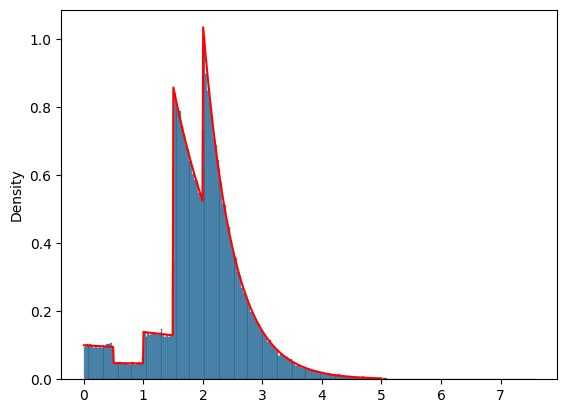

In [3]:
alpha = np.array([0.1, 0.05, 0.15, 1, 2])
s = np.array([0,0.5,1,1.5,2])
t = np.linspace(0.001, 5, 500)

h_t = pwexp.h(t, alpha, s)
H_t = pwexp.ch(t, alpha, s)
F_t = pwexp.cdf(t, alpha, s, lower_tail = True)
f_t = pwexp.pdf(t, alpha, s)
F_inv_t = pwexp.ppf(F_t, alpha, s)

sample_t = pwexp.rvs(alpha, s, size = 100000)

sns.histplot(x = sample_t, stat = "density")
plt.plot(t, f_t, color = "red")
# plt.plot(t, F_t)
# plt.plot(F_t, F_inv_t)
# plt.plot([0,np.max(t)], [0, np.max(t)])
plt.show()

To validate the implementation of our general model, we consider a simple data generating scheme with a single predictor variable, $x$.

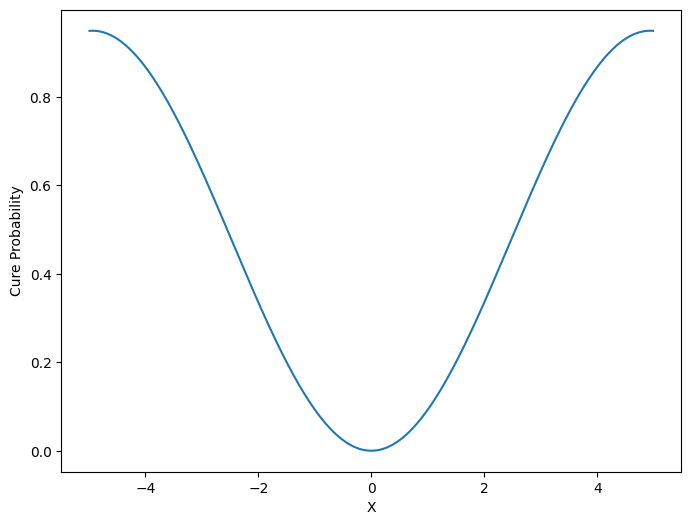

In [4]:
n = 1500

x = np.random.uniform(size = n, low = -5.0, high = 5.0)
p_true = np.sin(x / np.pi)**2 * 0.95

fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))
sns.lineplot(x = x, y = p_true, ax = ax)
ax.set_xlabel("X")
ax.set_ylabel("Cure Probability")
plt.show()

We consider the latent variables to follow a Poisson distribution merged with a standard Exp(1) distribution as a base distribution, $S_0$.

In [5]:
np.random.seed(10)
np.random.seed(1)

# n_train = 4000
# n_test = 1000

train_size = 0.7
n = 500
n_train = int(n * train_size)
n_test = n - n_train
print("n: {}".format(n))
print("n train: {}".format(n_train))
print("n test: {}".format(n_test))

x_train = np.random.uniform(size = n_train, low = -5.0, high = 5.0)
x_test = np.random.uniform(size = n_test, low = -5.0, high = 5.0)

p_true_train = np.sin(x_train / np.pi)**2 * 0.95
p_true_test = np.sin(x_test / np.pi)**2 * 0.95

# theta = C^{-1}( a0 / p )
# For the Poisson, we have C(theta) = e^theta, a0 = 1.0
theta_train = np.log( 1.0 / p_true_train )
theta_test = np.log( 1.0 / p_true_test )
q = 0.0

# m = np.random.poisson(size = n, lam = theta)
m_train = mps.rvs(log_a, log_phi, theta_train, q, sup(q)).numpy()
m_test = mps.rvs(log_a, log_phi, theta_test, q, sup(q)).numpy()
cured_train = (m_train == 0).astype("int")
cured_test = (m_test == 0).astype("int")

# Random uniform generators for the true lifetimes
u_train = np.random.uniform(size = np.sum(m_train > 0) )
u_test = np.random.uniform(size = np.sum(m_test > 0) )
# True lifetimes
y_true_train = np.repeat(np.inf, n_train)
y_true_test = np.repeat(np.inf, n_test)

y_true_train[m_train > 0] = -np.log(1 - u_train**(1/m_train[m_train > 0])) / theta_train[m_train > 0]
y_true_test[m_test > 0] = -np.log(1 - u_test**(1/m_test[m_test > 0])) / theta_test[m_test > 0]

y_censor_train = np.random.uniform(size = n_train, low = 0.0, high = 5.0)
y_censor_test = np.random.uniform(size = n_test, low = 0.0, high = 5.0)

y_train = y_true_train.copy()
y_test = y_true_test.copy()

delta_train = np.repeat(0, n_train)
delta_test = np.repeat(0, n_test)

# Define observed lifetimes as 1
delta_train[y_true_train <= y_censor_train] = 1
delta_test[y_true_test <= y_censor_test] = 1

# Censor lifetimes greater than censorship times
y_train[y_true_train > y_censor_train] = y_censor_train[y_true_train > y_censor_train]
y_test[y_true_test > y_censor_test] = y_censor_test[y_true_test > y_censor_test]

print("Proportion of censored (Train): {:.2f}%".format( (1-np.mean(delta_train))*100 ))
print("Proportion of censored (Test): {:.2f}%".format( (1-np.mean(delta_test))*100 ))

n: 500
n train: 350
n test: 150
Proportion of censored (Train): 61.14%
Proportion of censored (Test): 62.00%


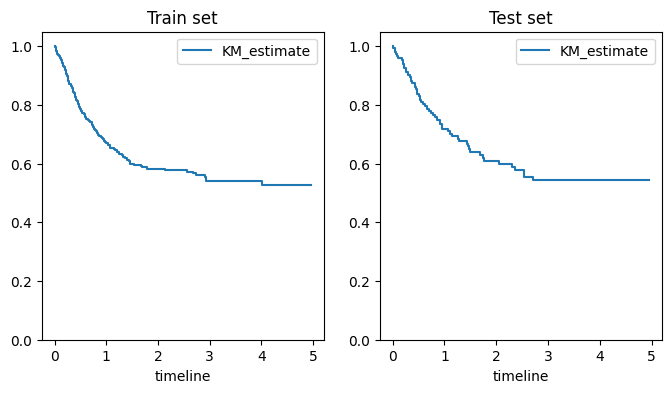

In [6]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (8,4))

km = lifelines.KaplanMeierFitter()
km.fit(y_train, delta_train)
km.plot(ax = ax[0], ci_show = False, show_censors = False)
ax[0].set_ylim(0,1.05)
ax[0].set_title("Train set")

km = lifelines.KaplanMeierFitter()
km.fit(y_test, delta_test)
km.plot(ax = ax[1], ci_show = False, show_censors = False)
ax[1].set_ylim(0,1.05)
ax[1].set_title("Test set")


plt.show()

In [7]:
def fit_model(dist,
              x_train, y_train, delta_train,
              x_test, y_test, delta_test,
              fixed_q = 0.0,
              finetune = True, get_covariances = True, seed = 10):
    '''
        Receives the name of a particular subfamily inside the two-parameter MPS family, fit the associated model
        and return all relevant results for this study.
    '''

    dist = dist.lower()
    if(dist == "poisson"):
        model_spec = mpscr.MPSPoisson()
    elif(dist == "bin" or dist == "binomial"):
        model_spec = mpscr.MPSBinomial(fixed_q)
    elif(dist == "negbin"):
        model_spec = mpscr.MPSNegBinomial()
    elif(dist == "geometric"):
        model_spec = mpscr.MPSNegBinomial(1.0)
    elif(dist == "log" or dist == "logarithmic"):
        model_spec = mpscr.MPSLogarithmic()
    elif(dist == "rgp"):
        model_spec = mpscr.MPSRGP()
    else:
        raise Exception("Please, provide a valid subfamily name.")

    data_train = [y_train, delta_train]
    data_test = [y_test, delta_test]
    
    with tf.device("/CPU:0"):
        model = mpscr.build_mpscr_model(y_train, delta_train, (1,), model_spec, seed = seed, n_cuts = 5)
        model.pre_train_model(epochs = None, x = x_train[:,None], data = data_train, shuffle = True)
        model.train_model(epochs = 5000, x = x_train[:,None], data = data_train,
                                  shuffle = True,
                                  get_covariances = get_covariances,
                                  validation = True, val_prop = 0.2, force_training_validation = False,
                                  optimizer_independent = optimizers.Adam(learning_rate = 0.01),
                                  optimizer_nn = optimizers.Adam(learning_rate = 0.01),
                                  fine_tune_nn_lr = 0.01, fine_tune_independent_lr = 0.01,
                                  early_stopping = True, early_stopping_patience = 50,
                                  early_stopping_warmup = 10, early_stopping_min_delta = 1.0e-3,
                                  reduce_lr = True, reduce_lr_warmup = 0,
                                  reduce_lr_factor = 0.5, reduce_lr_min_delta = 1.0e-3, reduce_lr_patience = 25,
                                  reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                                  fine_tune = finetune,
                                  finetune_early_stopping = True, finetune_early_stopping_patience = 50,
                                  finetune_early_stopping_warmup = 10, finetune_early_stopping_min_delta = 1.0e-2,
                                  finetune_reduce_lr = True, finetune_reduce_lr_warmup = 0,
                                  finetune_reduce_lr_factor = 0.5, finetune_reduce_lr_min_delta = 1.0e-2, finetune_reduce_lr_patience = 25,
                                  finetune_reduce_lr_cooldown = 10, finetune_reduce_lr_min_lr = 1.0e-5,
                                  deterministic = True,
                                  verbose = True, print_freq = 1)

    results_cure_model = model.get_survival_cure(y_train, x_train[:,None], y_test, x_test[:,None], ngrid = 100)
    return model, results_cure_model

### Poisson

In [8]:
data_train = [y_train, delta_train]
data_test = [y_test, delta_test]

poisson_spec = mpscr.MPSPoisson()
with tf.device("/CPU:0"):
    poisson_model = mpscr.build_mpscr_model(y_train, delta_train, (1,), poisson_spec, seed = 10, n_cuts = 5)
    poisson_model.pre_train_model(epochs = None, x = x_train[:,None], data = data_train, shuffle = True)
    poisson_model.train_model(epochs = 5000, x = x_train[:,None], data = data_train,
                              shuffle = True,
                              get_covariances = False,
                              validation = True, val_prop = 0.2, force_training_validation = False,
                              optimizer_independent = optimizers.Adam(learning_rate = 0.01),
                              optimizer_nn = optimizers.Adam(learning_rate = 0.01),
                              fine_tune_nn_lr = 0.01, fine_tune_independent_lr = 0.01,
                              early_stopping = True, early_stopping_patience = 50,
                              early_stopping_warmup = 10, early_stopping_min_delta = 1.0e-3,
                              reduce_lr = True, reduce_lr_warmup = 0,
                              reduce_lr_factor = 0.5, reduce_lr_min_delta = 1.0e-3, reduce_lr_patience = 25,
                              reduce_lr_cooldown = 10, reduce_lr_min_lr = 1.0e-5,
                              fine_tune = True,
                              finetune_early_stopping = True, finetune_early_stopping_patience = 50,
                              finetune_early_stopping_warmup = 10, finetune_early_stopping_min_delta = 1.0e-2,
                              finetune_reduce_lr = True, finetune_reduce_lr_warmup = 0,
                              finetune_reduce_lr_factor = 0.5, finetune_reduce_lr_min_delta = 1.0e-2, finetune_reduce_lr_patience = 25,
                              finetune_reduce_lr_cooldown = 10, finetune_reduce_lr_min_lr = 1.0e-5,
                              deterministic = True,
                              verbose = True, print_freq = 1)

Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 328 / 5000 ]  | Avg. Train NLL:  0.525374889 | Avg. Validation NLL:  0.597363412 | Best Avg. Validation NLL:  0.597363412 | Speed:  0.00248031202  epoch/s    | Elapsed Time:  0.813542366  s   
Convergence criterion reached. Stopping.
Optimizing... Epoch: [ 329 / 5000 ]  | Avg. Train NLL:  0.52537173 | Avg. Validation NLL:  0.597359836 | Best Avg. Validation NLL:  0.597359836 | Speed:  0.00247951341  epoch/s    | Elapsed Time:  0.815759897  s   Restoring best weights...

Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 58 / 5000 ]  | Avg. Train NLL:  0.525173843 | Best Avg. Train NLL:  0.525173843 | Avg. Validation NLL:  0.596823215 | Speed:  0.00230350578  epoch/s    | Elapsed Time:  0.133603334  s    
Convergence criterion reached. Stopping.
Optimizing... Epoch: [ 59 / 5000 ]  | Avg. Train NLL:  0.525172889 | Best Avg. Train NLL:  0.525172889 | Avg. Validation

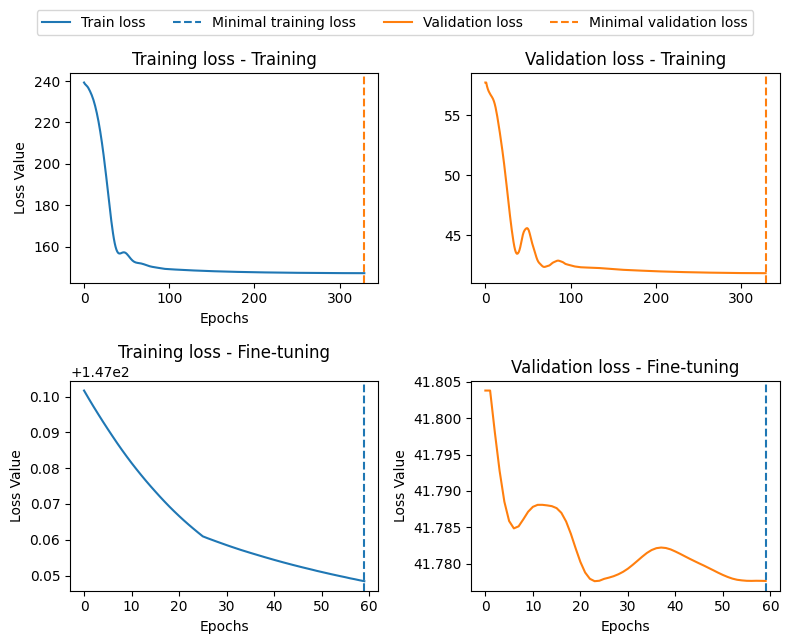

In [9]:
fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize = (8,6))

utils.plot_model_convergence( poisson_model, ax1 = ax[0,0], ax2 = ax[0,1], ax3 = ax[1,0], ax4 = ax[1,1] )

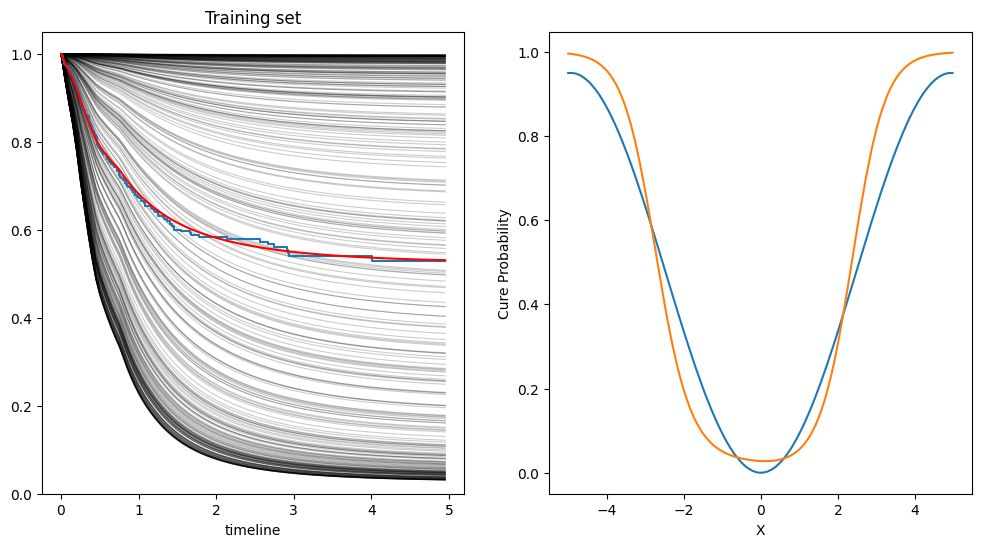

In [10]:
results_cure_poisson = poisson_model.get_survival_cure(y_train, x_train[:,None], y_test, x_test[:,None], ngrid = 100)

t = np.linspace(0.0001, np.max(np.concatenate([y_train, y_test])), 100)[:, None]

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))

utils.average_kaplan_meier(results_cure_poisson["ts_grid"], results_cure_poisson["S_ts_train"],
                           y_train, delta_train, show_individual = True, ax = ax[0])
ax[0].get_legend().remove()

sns.lineplot(x = x_train, y = p_true_train, ax = ax[1])
sns.lineplot(x = x_train, y = results_cure_poisson["p_train"], ax = ax[1])
ax[1].set_xlabel("X")
ax[1].set_ylabel("Cure Probability")

plt.show()

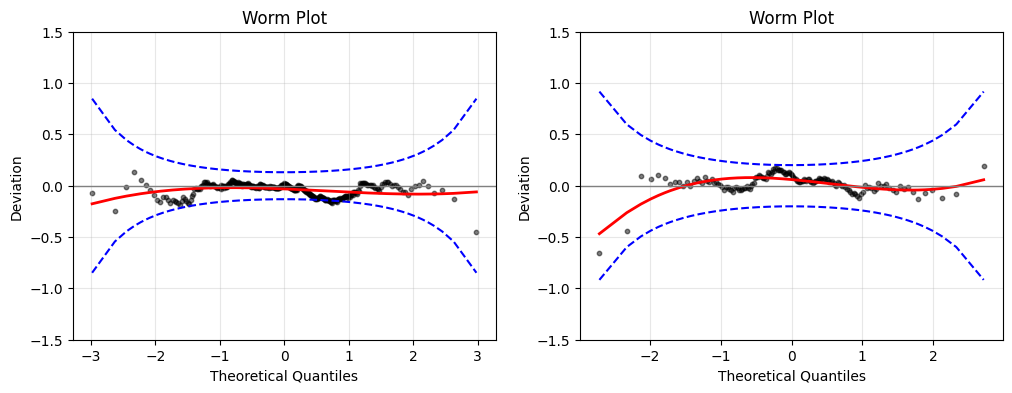

In [11]:
resid_train_poisson = utils.compute_randomized_residuals_censoring(results_cure_poisson["S_train"], delta_train)
resid_test_poisson = utils.compute_randomized_residuals_censoring(results_cure_poisson["S_test"], delta_test)

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,4))

utils.plot_worm( resid_train_poisson, ax = ax[0] )
utils.plot_worm( resid_test_poisson, ax = ax[1] )

# Fitting multiple models from the MPS

As shown above, the overall framework for the model is finished. Now, we are naturally interested in studying the behaviour of this model under misspecification. In particular, for this dataset, we considered the Poisson distribution as the generating process. Of all candidate models we can think in the MPS family, can we select the Poisson distributio as the winning model?

To do that, we incorporate the entire analysis from above into a single function, so we can obtain all the results for comparison using a single call.

In [12]:
poisson_model, results_cure_poisson = fit_model("poisson", x_train, y_train, delta_train, x_test, y_test, delta_test)
results_cure_poisson["resid_train"] = utils.compute_randomized_residuals_censoring(results_cure_poisson["S_train"], delta_train)
results_cure_poisson["resid_test"] = utils.compute_randomized_residuals_censoring(results_cure_poisson["S_test"], delta_test)

Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 328 / 5000 ]  | Avg. Train NLL:  0.525374889 | Avg. Validation NLL:  0.597363412 | Best Avg. Validation NLL:  0.597363412 | Speed:  0.00236493489  epoch/s    | Elapsed Time:  0.775698662  s   
Convergence criterion reached. Stopping.
Optimizing... Epoch: [ 329 / 5000 ]  | Avg. Train NLL:  0.52537173 | Avg. Validation NLL:  0.597359836 | Best Avg. Validation NLL:  0.597359836 | Speed:  0.00236565084  epoch/s    | Elapsed Time:  0.778299093  s   Restoring best weights...

Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 58 / 5000 ]  | Avg. Train NLL:  0.525173843 | Best Avg. Train NLL:  0.525173843 | Avg. Validation NLL:  0.596823215 | Speed:  0.00221931934  epoch/s    | Elapsed Time:  0.128720522  s    
Convergence criterion reached. Stopping.
Optimizing... Epoch: [ 59 / 5000 ]  | Avg. Train NLL:  0.525172889 | Best Avg. Train NLL:  0.525172889 | Avg. Validation

### Binomial

In [13]:
bin5_model, results_cure_bin5 = fit_model("bin", x_train, y_train, delta_train, x_test, y_test, delta_test, fixed_q = 5)
results_cure_bin5["resid_train"] = utils.compute_randomized_residuals_censoring(results_cure_bin5["S_train"], delta_train)
results_cure_bin5["resid_test"] = utils.compute_randomized_residuals_censoring(results_cure_bin5["S_test"], delta_test)

Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 128 / 5000 ]  | Avg. Train NLL:  0.530220389 | Avg. Validation NLL:  0.608592749 | Best Avg. Validation NLL:  0.60806042 | Speed:  0.00260735676  epoch/s    | Elapsed Time:  0.333741665  s    
Convergence criterion reached. Stopping.
Optimizing... Epoch: [ 129 / 5000 ]  | Avg. Train NLL:  0.530186236 | Avg. Validation NLL:  0.608515799 | Best Avg. Validation NLL:  0.60806042 | Speed:  0.00260877982  epoch/s    | Elapsed Time:  0.336532593  s   Restoring best weights...

Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 99 / 5000 ]  | Avg. Train NLL:  0.527381897 | Best Avg. Train NLL:  0.527381897 | Avg. Validation NLL:  0.602072656 | Speed:  0.00287563144  epoch/s    | Elapsed Time:  0.284687519  s    
Convergence criterion reached. Stopping.
Restoring best weights...
Optimizing... Epoch: [ 100 / 5000 ]  | Avg. Train NLL:  0.527379 | Best Avg. Train NLL:  0.527

### Negative Binomial (Mean-Variance parametrization)

In [14]:
nb_model, results_cure_nb = fit_model("negbin", x_train, y_train, delta_train, x_test, y_test, delta_test, fixed_q = 5)
results_cure_nb["resid_train"] = utils.compute_randomized_residuals_censoring(results_cure_nb["S_train"], delta_train)
results_cure_nb["resid_test"] = utils.compute_randomized_residuals_censoring(results_cure_nb["S_test"], delta_test)

Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 275 / 5000 ]  | Avg. Train NLL:  0.526346087 | Avg. Validation NLL:  0.594364464 | Best Avg. Validation NLL:  0.594301581 | Speed:  0.00273650861  epoch/s    | Elapsed Time:  0.752539873  s   
Convergence criterion reached. Stopping.
Optimizing... Epoch: [ 276 / 5000 ]  | Avg. Train NLL:  0.526338458 | Avg. Validation NLL:  0.594367743 | Best Avg. Validation NLL:  0.594301581 | Speed:  0.00273823226  epoch/s    | Elapsed Time:  0.755752087  s   Restoring best weights...

Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 58 / 5000 ]  | Avg. Train NLL:  0.526125 | Best Avg. Train NLL:  0.526125 | Avg. Validation NLL:  0.593995154 | Speed:  0.00270748953  epoch/s    | Elapsed Time:  0.157034397  s     s    
Convergence criterion reached. Stopping.
Optimizing... Epoch: [ 59 / 5000 ]  | Avg. Train NLL:  0.526121795 | Best Avg. Train NLL:  0.526121795 | Avg. Validatio

### Geometric

In [15]:
geometric_model, results_cure_geometric = fit_model("geometric", x_train, y_train, delta_train, x_test, y_test, delta_test, fixed_q = 5)
results_cure_geometric["resid_train"] = utils.compute_randomized_residuals_censoring(results_cure_geometric["S_train"], delta_train)
results_cure_geometric["resid_test"] = utils.compute_randomized_residuals_censoring(results_cure_geometric["S_test"], delta_test)

Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 364 / 5000 ]  | Avg. Train NLL:  0.535882771 | Avg. Validation NLL:  0.594988048 | Best Avg. Validation NLL:  0.594988 | Speed:  0.00286499294  epoch/s    | Elapsed Time:  1.04285741  s       
Convergence criterion reached. Stopping.
Optimizing... Epoch: [ 365 / 5000 ]  | Avg. Train NLL:  0.535872519 | Avg. Validation NLL:  0.594988465 | Best Avg. Validation NLL:  0.594988 | Speed:  0.00286583835  epoch/s    | Elapsed Time:  1.046031  s   Restoring best weights...

Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 58 / 5000 ]  | Avg. Train NLL:  0.535370767 | Best Avg. Train NLL:  0.535370767 | Avg. Validation NLL:  0.594435513 | Speed:  0.00265739299  epoch/s    | Elapsed Time:  0.15412879  s     
Convergence criterion reached. Stopping.
Optimizing... Epoch: [ 59 / 5000 ]  | Avg. Train NLL:  0.535365939 | Best Avg. Train NLL:  0.535365939 | Avg. Validation NLL:

### Logarithmic

In [16]:
model_log_spec = mpscr.MPSLogarithmic()

log_model, results_cure_log = fit_model("log", x_train, y_train, delta_train, x_test, y_test, delta_test, fixed_q = 5)
results_cure_log["resid_train"] = utils.compute_randomized_residuals_censoring(results_cure_log["S_train"], delta_train)
results_cure_log["resid_test"] = utils.compute_randomized_residuals_censoring(results_cure_log["S_test"], delta_test)

Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 385 / 5000 ]  | Avg. Train NLL:  0.56995064 | Avg. Validation NLL:  0.614768803 | Best Avg. Validation NLL:  0.614582658 | Speed:  0.00743412087  epoch/s    | Elapsed Time:  2.8621366  s      
Convergence criterion reached. Stopping.
Optimizing... Epoch: [ 386 / 5000 ]  | Avg. Train NLL:  0.569923341 | Avg. Validation NLL:  0.614776373 | Best Avg. Validation NLL:  0.614582658 | Speed:  0.00743729295  epoch/s    | Elapsed Time:  2.87079501  s   Restoring best weights...

Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 80 / 5000 ]  | Avg. Train NLL:  0.568997085 | Best Avg. Train NLL:  0.568997085 | Avg. Validation NLL:  0.612841368 | Speed:  0.00777054438  epoch/s    | Elapsed Time:  0.621643543  s    
Convergence criterion reached. Stopping.
Optimizing... Epoch: [ 81 / 5000 ]  | Avg. Train NLL:  0.568984866 | Best Avg. Train NLL:  0.568984866 | Avg. Validation

### RGP

In [17]:
rgp_model, results_cure_rgp = fit_model("rgp", x_train, y_train, delta_train, x_test, y_test, delta_test, fixed_q = 5)
results_cure_rgp["resid_train"] = utils.compute_randomized_residuals_censoring(results_cure_rgp["S_train"], delta_train)
results_cure_rgp["resid_test"] = utils.compute_randomized_residuals_censoring(results_cure_rgp["S_test"], delta_test)

Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 172 / 5000 ]  | Avg. Train NLL:  0.528047502 | Avg. Validation NLL:  0.597376406 | Best Avg. Validation NLL:  0.592924654 | Speed:  0.00314820791  epoch/s    | Elapsed Time:  0.541491747  s   
Convergence criterion reached. Stopping.
Optimizing... Epoch: [ 173 / 5000 ]  | Avg. Train NLL:  0.5280056 | Avg. Validation NLL:  0.597400844 | Best Avg. Validation NLL:  0.592924654 | Speed:  0.00314819044  epoch/s    | Elapsed Time:  0.544636965  s   Restoring best weights...

Done.
Initializing model fine tuning (only independent parameters and last-layer)
Optimizing... Epoch: [ 104 / 5000 ]  | Avg. Train NLL:  0.5268327 | Best Avg. Train NLL:  0.5268327 | Avg. Validation NLL:  0.595524848 | Speed:  0.00279827532  epoch/s    | Elapsed Time:  0.291020632  s   s   
Convergence criterion reached. Stopping.
Optimizing... Epoch: [ 105 / 5000 ]  | Avg. Train NLL:  0.526830733 | Best Avg. Train NLL:  0.526830733 | Avg. Validation

# Comparing all models

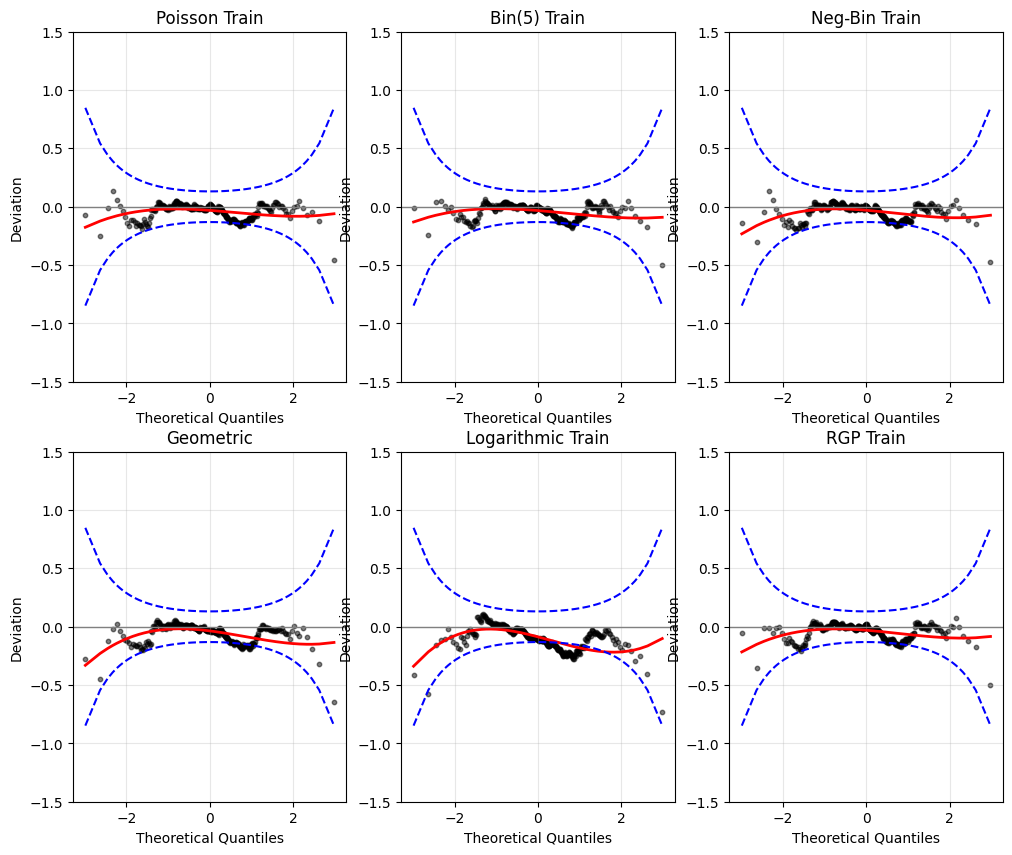

In [18]:
fig, ax = plt.subplots(nrows = 2, ncols = 3, figsize = (12,10))

utils.plot_worm( results_cure_poisson["resid_train"], ax = ax[0,0] )
ax[0,0].set_title("Poisson Train")
utils.plot_worm( results_cure_bin5["resid_train"], ax = ax[0,1] )
ax[0,1].set_title("Bin(5) Train")
utils.plot_worm( results_cure_nb["resid_train"], ax = ax[0,2] )
ax[0,2].set_title("Neg-Bin Train")
utils.plot_worm( results_cure_geometric["resid_train"], ax = ax[1,0] )
ax[1,0].set_title("Geometric")
utils.plot_worm( results_cure_log["resid_train"], ax = ax[1,1] )
ax[1,1].set_title("Logarithmic Train")
utils.plot_worm( results_cure_rgp["resid_train"], ax = ax[1,2] )
ax[1,2].set_title("RGP Train")
plt.show()

### Final models

In [19]:
print("Second parameter values")
print("Poisson: ---")
print("Bin(5): 5")
print("NegBin: {:.4f}".format(nb_model.predict("q")[0]))
print("Geometric: ---")
print("Logarithmic: ---")
print("RGP: {:.4f}".format(rgp_model.predict("q")[0]))

Second parameter values
Poisson: ---
Bin(5): 5
NegBin: 0.2540
Geometric: ---
Logarithmic: ---
RGP: 0.0211


In [20]:
from scipy.stats import anderson

In [21]:
ad_poisson = anderson( results_cure_poisson["resid_test"] ).statistic
ad_bin5 = anderson( results_cure_bin5["resid_test"] ).statistic
ad_nb = anderson( results_cure_nb["resid_test"] ).statistic
ad_geometric = anderson( results_cure_geometric["resid_test"] ).statistic
ad_log = anderson( results_cure_log["resid_test"] ).statistic
ad_rgp = anderson( results_cure_rgp["resid_test"] ).statistic

ad_results = pd.DataFrame({"Set": ["Test", "Test", "Test", "Test", "Test", "Test"],
                           "Model": ["Poisson", "Bin5", "NegBin", "Geometric", "Logarithmic", "RGP"],
                           "ad_statistic": [ad_poisson, ad_bin5, ad_nb, ad_geometric, ad_log, ad_rgp]})
ad_results.sort_values(by = "ad_statistic")

,Set,Model,ad_statistic
1,Test,Bin5,0.351444
0,Test,Poisson,0.352624
5,Test,RGP,0.365154
2,Test,NegBin,0.365667
4,Test,Logarithmic,0.384191
3,Test,Geometric,0.421508
